In [ ]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt
from more_itertools import split_when
from tqdm import tqdm
from dotenv import load_dotenv

from rfml_uav.drone_rf.consts import BUI
from rfml_uav.drone_rf.utils import get_segment_count

load_dotenv()

True

In [2]:
# Path of raw RF data
load_path = os.path.join(os.getenv("DATA_PATH"), "raw")
save_path = os.path.join(os.getenv("DATA_PATH"), "chunked")
os.makedirs(save_path, exist_ok=True)

chunk_size = 4000
min_power = 200
threshold = 0.3
min_packet_length = chunk_size / 2

In [3]:
# Optimized function to compute signal energy using a sliding window approach
def compute_signal_energy_optimized(signal, window_size):
    # Compute the energy of the signal using a sliding window approach
    energy = np.zeros(len(signal) - window_size + 1)
    
    # Calculate the initial energy for the first window
    energy[0] = np.sum(signal[:window_size] ** 2)
    
    # Use a sliding window technique to compute energy for subsequent windows
    for i in range(1, len(energy)):
        energy[i] = energy[i - 1] - signal[i - 1] ** 2 + signal[i + window_size - 1] ** 2
    
    return energy


# Function to detect RF packets based on energy thresholding
def detect_rf_packets(signal, threshold=0.5, min_power=200, window_size=10):
    energy = compute_signal_energy_optimized(signal, window_size)

    threshold_energy = max((np.max(energy) * threshold, min_power))

    # Detect regions where energy exceeds the threshold
    rf_packet_indices = np.where(energy > threshold_energy)[0]

    return rf_packet_indices


def get_chunk_ids(data, chunk_size=4000, min_packet_length=40):
    min_index = 0
    max_index = len(data) - 1

    packet_ids = detect_rf_packets(
        data,
        threshold=threshold,
        min_power=min_power,
    )

    chunk_ids = []
    for ids in split_when(packet_ids, lambda a, b: a + min_packet_length < b):
        if len(ids) < 2:
            continue

        mid = math.floor((ids[0] + ids[-1]) / 2)
        start = mid - int(chunk_size / 2)
        end = mid + int(chunk_size / 2)

        if start < min_index:
            offset = min_index - start
            start += offset
            end += offset
        elif end > max_index:
            offset = end - max_index
            start -= offset
            end -= offset

        chunk_ids.append([start, end])
    return chunk_ids

In [ ]:
for bui in BUI:
    is_background_noise = bui == '00000'
    N = get_segment_count(bui)

    data = []

    for n in tqdm(range(N)):
        # Loading raw CSV files
        x = np.loadtxt(os.path.join(load_path, f"{bui}L_{n}.csv"), delimiter=',')
        y = np.loadtxt(os.path.join(load_path, f"{bui}H_{n}.csv"), delimiter=',')

        x_chunks = []
        y_chunks = []
        
        if is_background_noise:
            x_chunks = [x[i:i+chunk_size] for i in range(0, len(x), chunk_size)]
            y_chunks = [y[i:i+chunk_size] for i in range(0, len(y), chunk_size)]
        else:
            x_ids = get_chunk_ids(x, chunk_size=chunk_size)
            y_ids = get_chunk_ids(y, chunk_size=chunk_size)
            
            chunk_ids = np.unique(np.concat((x_ids, y_ids)), axis=0)

            x_chunks = [x[start: end] for start, end in chunk_ids]
            y_chunks = [y[start: end] for start, end in chunk_ids]

        np.savez_compressed(os.path.join(save_path, f'{bui}L_{n}.npz'), x_chunks)
        np.savez_compressed(os.path.join(save_path, f'{bui}H_{n}.npz'), y_chunks)

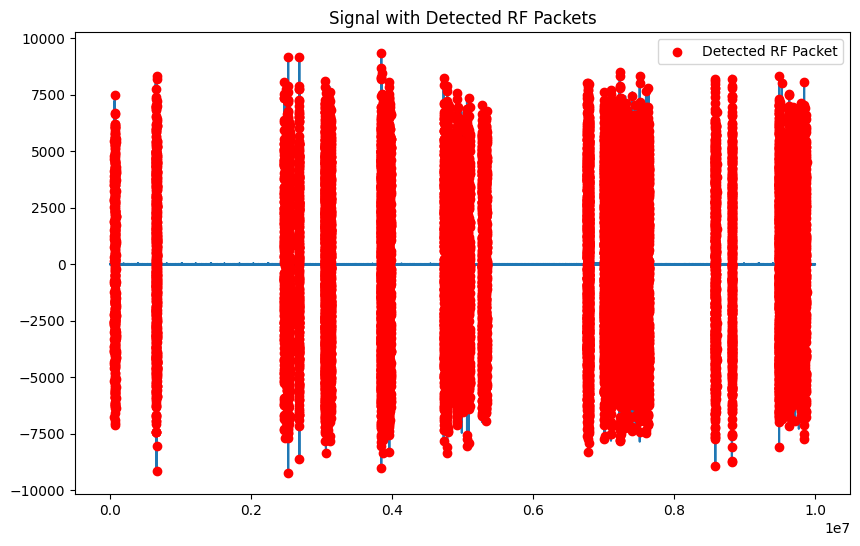

In [5]:
bui = BUI[1]
n = 0
x = np.loadtxt(os.path.join(load_path, f"{bui}L_{n}.csv"), delimiter=',')

x_ids = detect_rf_packets(x, threshold=threshold, min_power=min_power)


# Visualize the signal with detected RF packets
plt.figure(figsize=(10, 6))
plt.plot(x)
plt.scatter(x_ids, x[x_ids], color='red', label='Detected RF Packet', zorder=5)
plt.title("Signal with Detected RF Packets")
plt.legend()
plt.show()